# VAE experiments — paper-like SMILES vs V2 SELFIES

This notebook lets you directly compare:

- **Paper-like VAE**: close to the Gómez-Bombarelli / `molecular-vae` style (conv encoder + GRU decoder) using **character-level SMILES**.
- **V2 VAE (adapted)**: your smaller-capacity architecture, but trained on **SELFIES tokens** for easier valid decoding.

Both models are evaluated on the **same 5 test molecules** (original SMILES vs reconstructed output), with an RDKit validity check.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary

import deepchem as dc
from rdkit import Chem

print('torch', torch.__version__)

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/Users/iamthomaspruyn/Documents/PhD/Projects/AI-for-Toxicology/AI-for-Toxicology/.venv/lib/python3.11/site-packages/deepchem/models/torch_models/__init_

torch 2.10.0


In [7]:
# SELFIES (install if needed)
try:
    import selfies as sf
except ImportError:
    import sys
    !{sys.executable} -m pip -q install selfies
    import selfies as sf

print('selfies', sf.__version__)

selfies 2.1.1


In [8]:
# Load Tox21 with a persistent cache (avoids temp-folder metadata errors)
DATA_DIR = 'data'
SAVE_DIR = 'data/tox21-cache'

try:
    tasks, datasets, transformers = dc.molnet.load_tox21(
        featurizer='Raw',
        reload=False,
        data_dir=DATA_DIR,
        save_dir=SAVE_DIR,
    )
except Exception:
    tasks, datasets, transformers = dc.molnet.load_tox21(
        featurizer='Raw',
        reload=True,
        data_dir=DATA_DIR,
        save_dir=SAVE_DIR,
    )

train_dataset, valid_dataset, test_dataset = datasets

train_smiles = [Chem.MolToSmiles(m) for m in train_dataset.X]
valid_smiles = [Chem.MolToSmiles(m) for m in valid_dataset.X]
test_smiles  = [Chem.MolToSmiles(m) for m in test_dataset.X]

print('raw counts:', len(train_smiles), len(valid_smiles), len(test_smiles))

[14:59:52] WARNING: not removing hydrogen atom without neighbors
[14:59:52] Explicit valence for atom # 8 Al, 6, is greater than permitted
Failed to featurize datapoint 1322, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True, bool includeAtomMaps=True, bool includeChiralPresence=False)
[14:59:52] Explicit valence for atom # 3 Al, 6, is greater than permitted
Failed to featurize datapoint 2290, None. Appending empty array
Exception message: Python argument types in
    rdkit.Chem.rdmolfiles.CanonicalRankAtoms(NoneType)
did not match C++ signature:
    CanonicalRankAtoms(RDKit::ROMol mol, bool breakTies=True, bool includeChirality=True, bool includeIsotopes=True, bool includeAtomMaps=True, bool includeChiralPresence=False)
[14:59:52] Explicit valence for atom # 4 Al, 6,

raw counts: 6258 782 783


In [9]:
# Keep the Baseline spirit: cap by SMILES length
MAX_SMILES_LEN = 60

def filter_by_len(smiles_list, max_len=MAX_SMILES_LEN):
    return [s for s in smiles_list if len(s) <= max_len]

def report_filter(name, smiles_list):
    n0 = len(smiles_list)
    kept = filter_by_len(smiles_list)
    n1 = len(kept)
    print(f"{name}: kept {n1}/{n0} ({100*n1/n0:.1f}%) with len <= {MAX_SMILES_LEN}")
    return kept

train_smiles = report_filter('train', train_smiles)
valid_smiles = report_filter('valid', valid_smiles)
test_smiles  = report_filter('test',  test_smiles)

train: kept 5721/6258 (91.4%) with len <= 60
valid: kept 577/782 (73.8%) with len <= 60
test: kept 597/783 (76.2%) with len <= 60


In [ ]:
# Convert to SELFIES (drop any molecules that fail encoding so both models see the same test items)
def smiles_to_selfies(smiles_list):
    kept_smiles = []
    kept_selfies = []
    for s in smiles_list:
        try:
            se = sf.encoder(s)
        except Exception:
            se = None
        if se is None:
            continue
        kept_smiles.append(s)
        kept_selfies.append(se)
    return kept_smiles, kept_selfies

train_smiles, train_selfies = smiles_to_selfies(train_smiles)
valid_smiles, valid_selfies = smiles_to_selfies(valid_smiles)
test_smiles,  test_selfies  = smiles_to_selfies(test_smiles)

print('SELFIES encodable counts:', len(train_selfies), len(valid_selfies), len(test_selfies))

SELFIES encodable counts: 5721 577 597


## A) Paper-like pipeline (character-level SMILES)

In [11]:
PAD = '<PAD>'
UNK = '<UNK>'
EOS = '<EOS>'

paper_all_chars = [PAD, UNK, EOS] + sorted(set(''.join(train_smiles)))
paper_char_to_idx = {c: i for i, c in enumerate(paper_all_chars)}
paper_idx_to_char = {i: c for c, i in paper_char_to_idx.items()}
paper_PAD_IDX = paper_char_to_idx[PAD]
paper_EOS_IDX = paper_char_to_idx[EOS]

def paper_tokenize(smiles: str):
    ids = [paper_char_to_idx.get(ch, paper_char_to_idx[UNK]) for ch in smiles]
    ids.append(paper_EOS_IDX)
    return ids

paper_train_tok = [paper_tokenize(s) for s in train_smiles]
paper_valid_tok = [paper_tokenize(s) for s in valid_smiles]
paper_test_tok  = [paper_tokenize(s) for s in test_smiles]

paper_vocab_size = len(paper_all_chars)
paper_seq_len = max(len(x) for x in paper_train_tok)

def one_hot_encode(token_seqs, seq_len, vocab_size, pad_idx):
    X = np.zeros((len(token_seqs), seq_len, vocab_size), dtype=np.float32)
    X[:, :, pad_idx] = 1.0
    for i, seq in enumerate(token_seqs):
        for t, idx in enumerate(seq[:seq_len]):
            X[i, t, pad_idx] = 0.0
            X[i, t, idx] = 1.0
    return X

paper_train_X = one_hot_encode(paper_train_tok, paper_seq_len, paper_vocab_size, paper_PAD_IDX)
paper_valid_X = one_hot_encode(paper_valid_tok, paper_seq_len, paper_vocab_size, paper_PAD_IDX)
paper_test_X  = one_hot_encode(paper_test_tok,  paper_seq_len, paper_vocab_size, paper_PAD_IDX)

def decode_one_hot_smiles(x_vocab_seq, idx_to_char, pad_char=PAD, eos_char=EOS):
    token_ids = x_vocab_seq.argmax(axis=0)
    out = []
    for i in token_ids:
        ch = idx_to_char[int(i)]
        if ch == eos_char:
            break
        if ch == pad_char:
            continue
        out.append(ch)
    return ''.join(out)

print('paper vocab/seq:', paper_vocab_size, paper_seq_len)
print('paper shapes:', paper_train_X.shape, paper_valid_X.shape, paper_test_X.shape)

paper vocab/seq: 54 61
paper shapes: (5721, 61, 54) (577, 61, 54) (597, 61, 54)


## B) V2 pipeline (token-level SELFIES)

In [12]:
v2_PAD = '<PAD>'
v2_UNK = '<UNK>'
v2_EOS = '<EOS>'

def selfies_tokenize(selfies_str: str):
    return list(sf.split_selfies(selfies_str))

v2_train_tokens = [selfies_tokenize(s) for s in train_selfies]
v2_vocab_tokens = sorted({tok for seq in v2_train_tokens for tok in seq})
v2_all_tokens = [v2_PAD, v2_UNK, v2_EOS] + v2_vocab_tokens
v2_token_to_idx = {t: i for i, t in enumerate(v2_all_tokens)}
v2_idx_to_token = {i: t for t, i in v2_token_to_idx.items()}
v2_PAD_IDX = v2_token_to_idx[v2_PAD]
v2_EOS_IDX = v2_token_to_idx[v2_EOS]

def v2_encode(selfies_str: str):
    unk = v2_token_to_idx[v2_UNK]
    toks = selfies_tokenize(selfies_str)
    ids = [v2_token_to_idx.get(t, unk) for t in toks]
    ids.append(v2_EOS_IDX)
    return ids

v2_train_tok = [v2_encode(s) for s in train_selfies]
v2_valid_tok = [v2_encode(s) for s in valid_selfies]
v2_test_tok  = [v2_encode(s) for s in test_selfies]

v2_vocab_size = len(v2_all_tokens)
v2_seq_len = max(len(x) for x in v2_train_tok)

v2_train_X = one_hot_encode(v2_train_tok, v2_seq_len, v2_vocab_size, v2_PAD_IDX)
v2_valid_X = one_hot_encode(v2_valid_tok, v2_seq_len, v2_vocab_size, v2_PAD_IDX)
v2_test_X  = one_hot_encode(v2_test_tok,  v2_seq_len, v2_vocab_size, v2_PAD_IDX)

def decode_one_hot_selfies(x_vocab_seq, idx_to_token, pad_tok=v2_PAD, eos_tok=v2_EOS):
    token_ids = x_vocab_seq.argmax(axis=0)
    out = []
    for i in token_ids:
        tok = idx_to_token[int(i)]
        if tok == eos_tok:
            break
        if tok == pad_tok:
            continue
        out.append(tok)
    return ''.join(out)

def selfies_to_smiles(selfies_str: str):
    try:
        return sf.decoder(selfies_str)
    except Exception:
        return None

print('v2 vocab/seq:', v2_vocab_size, v2_seq_len)
print('v2 shapes:', v2_train_X.shape, v2_valid_X.shape, v2_test_X.shape)

v2 vocab/seq: 150 64
v2 shapes: (5721, 64, 150) (577, 64, 150) (597, 64, 150)


## Models + training loops

In [13]:
class PaperVAE(nn.Module):
    def __init__(self, vocab_size, seq_len, latent_dim=292):
        super().__init__()
        self.seq_len = seq_len
        self.conv_1 = nn.Conv1d(in_channels=seq_len, out_channels=9, kernel_size=9)
        self.conv_2 = nn.Conv1d(in_channels=9, out_channels=9, kernel_size=9)
        self.conv_3 = nn.Conv1d(in_channels=9, out_channels=10, kernel_size=11)
        self.relu = nn.ReLU()

        with torch.no_grad():
            dummy = torch.zeros(1, seq_len, vocab_size)
            d = self.relu(self.conv_1(dummy))
            d = self.relu(self.conv_2(d))
            d = self.relu(self.conv_3(d))
            flat = d.view(1, -1).size(1)

        self.linear_0 = nn.Linear(flat, 435)
        self.linear_1 = nn.Linear(435, latent_dim)
        self.linear_2 = nn.Linear(435, latent_dim)

        self.linear_3 = nn.Linear(latent_dim, 292)
        self.gru = nn.GRU(input_size=292, hidden_size=501, num_layers=3, batch_first=True)
        self.linear_4 = nn.Linear(501, vocab_size)

    def encoder(self, x):
        x = self.relu(self.conv_1(x))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))
        x = x.view(x.size(0), -1)
        x = F.selu(self.linear_0(x))
        return self.linear_1(x), self.linear_2(x)

    def sampling(self, z_mean, z_logvar):
        eps = 1e-2 * torch.randn_like(z_logvar)
        return torch.exp(0.5 * z_logvar) * eps + z_mean

    def decode(self, z):
        z = F.selu(self.linear_3(z))
        z_seq = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.gru(z_seq)
        out2 = out.contiguous().view(-1, out.size(-1))
        probs = F.softmax(self.linear_4(out2), dim=1)
        return probs.contiguous().view(out.size(0), -1, probs.size(-1))

    def forward(self, x):
        mean, logvar = self.encoder(x)
        z = self.sampling(mean, logvar)
        return self.decode(z), mean, logvar


def paper_loss(pred_probs, x_onehot, mean, logvar):
    recon = F.binary_cross_entropy(pred_probs, x_onehot, reduction='sum')
    kl = -0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp())
    return recon + kl


def train_paper(model, train_X, valid_X, device, *, epochs=30, batch_size=250, lr=1e-3):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(TensorDataset(torch.from_numpy(train_X).float()), batch_size=batch_size, shuffle=True, drop_last=True)
    valid_loader = DataLoader(TensorDataset(torch.from_numpy(valid_X).float()), batch_size=batch_size, shuffle=False)

    train_losses, val_losses = [], []
    for ep in range(1, epochs + 1):
        model.train()
        tsum = 0.0
        for batch in train_loader:
            x = batch[0].to(device)
            opt.zero_grad()
            preds, mean, logvar = model(x)
            loss = paper_loss(preds, x, mean, logvar)
            loss.backward()
            opt.step()
            tsum += loss.item()
        train_losses.append(tsum / len(train_loader.dataset))

        model.eval()
        vsum = 0.0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[0].to(device)
                preds, mean, logvar = model(x)
                vsum += paper_loss(preds, x, mean, logvar).item()
        val_losses.append(vsum / len(valid_loader.dataset))

        print(f"paper ep {ep}: train={train_losses[-1]:.4f} val={val_losses[-1]:.4f}")

    return model, train_losses, val_losses

In [14]:
class V2SelfiesVAE(nn.Module):
    def __init__(self, vocab_size, seq_len, latent_dim=32):
        super().__init__()
        self.seq_len = seq_len

        self.conv_1 = nn.Conv1d(in_channels=seq_len, out_channels=8, kernel_size=9)
        self.conv_2 = nn.Conv1d(in_channels=8, out_channels=8, kernel_size=9)
        self.conv_3 = nn.Conv1d(in_channels=8, out_channels=10, kernel_size=11)
        self.relu = nn.ReLU()

        enc_hidden_dim = 256
        self.linear_0 = nn.LazyLinear(enc_hidden_dim)
        self.linear_1 = nn.Linear(enc_hidden_dim, latent_dim)
        self.linear_2 = nn.Linear(enc_hidden_dim, latent_dim)

        dec_input_dim = 32
        rnn_hidden_dim = 64
        rnn_layers = 1

        self.linear_3 = nn.Linear(latent_dim, dec_input_dim)
        self.gru = nn.GRU(input_size=dec_input_dim, hidden_size=rnn_hidden_dim, num_layers=rnn_layers, batch_first=True)
        self.linear_4 = nn.Linear(rnn_hidden_dim, vocab_size)

    def encoder(self, x):
        x = self.relu(self.conv_1(x))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))
        x = x.view(x.size(0), -1)
        x = F.selu(self.linear_0(x))
        return self.linear_1(x), self.linear_2(x)

    def sampling(self, mean, logvar):
        eps = 1e-2 * torch.randn_like(logvar)
        return torch.exp(0.5 * logvar) * eps + mean

    def decode(self, z):
        z = F.selu(self.linear_3(z))
        z_seq = z.unsqueeze(1).repeat(1, self.seq_len, 1)
        out, _ = self.gru(z_seq)
        logits = self.linear_4(out)
        return logits

    def forward(self, x):
        mean, logvar = self.encoder(x)
        z = self.sampling(mean, logvar)
        return self.decode(z), mean, logvar


def v2_vae_loss(logits, x_one_hot, mean, logvar, *, pad_idx: int, beta: float = 1.0, free_bits_nats: float = 0.0):
    targets = x_one_hot.argmax(dim=-1)
    vocab_size = logits.size(-1)

    recon_sum = F.cross_entropy(
        logits.reshape(-1, vocab_size),
        targets.reshape(-1),
        ignore_index=pad_idx,
        reduction='sum',
    )

    kl_per_dim = -0.5 * (1 + logvar - mean.pow(2) - logvar.exp())
    if free_bits_nats and free_bits_nats > 0:
        kl_per_dim = torch.clamp(kl_per_dim, min=float(free_bits_nats))
    kl_sum = kl_per_dim.sum()

    n_nonpad = (targets != pad_idx).sum().clamp(min=1)
    total = recon_sum + beta * kl_sum
    return total, recon_sum, kl_sum, n_nonpad


def kl_beta(epoch: int, anneal_epochs: int) -> float:
    if anneal_epochs <= 1:
        return 1.0
    return float(min(1.0, epoch / anneal_epochs))


def train_v2(model, train_X, valid_X, device, *, epochs=50, anneal_epochs=150, free_bits_nats=0.1, batch_size=64, lr=1e-4):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(TensorDataset(torch.from_numpy(train_X).float()), batch_size=batch_size, shuffle=True, drop_last=True)
    valid_loader = DataLoader(TensorDataset(torch.from_numpy(valid_X).float()), batch_size=batch_size, shuffle=False)

    train_total, val_total = [], []

    for ep in range(1, epochs + 1):
        beta = kl_beta(ep, anneal_epochs)

        model.train()
        tot = 0.0
        for batch in train_loader:
            x = batch[0].to(device)
            opt.zero_grad()
            logits, mean, logvar = model(x)
            loss, _, _, _ = v2_vae_loss(logits, x, mean, logvar, pad_idx=v2_PAD_IDX, beta=beta, free_bits_nats=free_bits_nats)
            loss.backward()
            opt.step()
            tot += loss.item()
        train_total.append(tot / len(train_loader.dataset))

        model.eval()
        vtot = 0.0
        with torch.no_grad():
            for batch in valid_loader:
                x = batch[0].to(device)
                logits, mean, logvar = model(x)
                loss, _, _, _ = v2_vae_loss(logits, x, mean, logvar, pad_idx=v2_PAD_IDX, beta=beta, free_bits_nats=free_bits_nats)
                vtot += loss.item()
        val_total.append(vtot / len(valid_loader.dataset))

        print(f"v2 ep {ep}: beta={beta:.2f} train={train_total[-1]:.4f} val={val_total[-1]:.4f}")

    return model, train_total, val_total

paper params
v2 params
paper ep 1: train=167.5635 val=185.3017
paper ep 2: train=123.7355 val=166.7400
paper ep 3: train=101.1566 val=145.1082
paper ep 4: train=95.2647 val=141.0683
paper ep 5: train=91.1090 val=138.1350
paper ep 6: train=92.4255 val=141.4013
paper ep 7: train=91.7377 val=140.5958
paper ep 8: train=88.2773 val=135.5582
paper ep 9: train=88.1358 val=134.5266
paper ep 10: train=88.9127 val=137.1666
paper ep 11: train=88.1162 val=135.4822
paper ep 12: train=87.1464 val=134.4554
paper ep 13: train=88.7525 val=143.8770
paper ep 14: train=87.1583 val=133.7665
paper ep 15: train=84.9056 val=134.4202
paper ep 16: train=84.9593 val=160.8349
paper ep 17: train=97.1917 val=141.6450
paper ep 18: train=87.7330 val=134.0910
paper ep 19: train=85.2375 val=137.4596
paper ep 20: train=88.2073 val=157.2781
paper ep 21: train=87.2739 val=134.8956
paper ep 22: train=83.5592 val=129.4963
paper ep 23: train=84.4188 val=129.1487
paper ep 24: train=80.8067 val=127.7227
paper ep 25: train=79.0

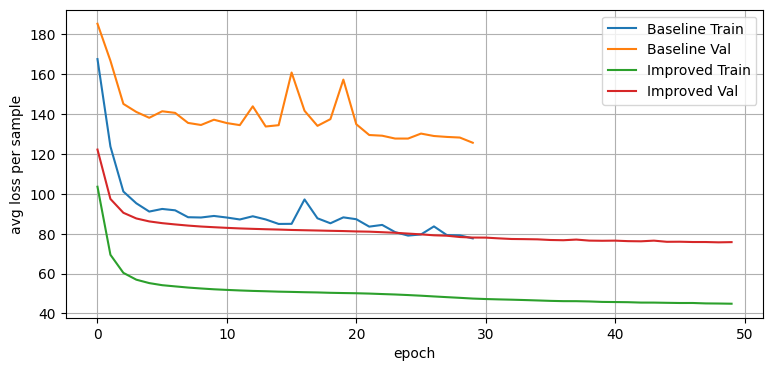

In [21]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')

PAPER_EPOCHS = 30
V2_EPOCHS = 50

paper_model = PaperVAE(vocab_size=paper_vocab_size, seq_len=paper_seq_len).to(device)
v2_model = V2SelfiesVAE(vocab_size=v2_vocab_size, seq_len=v2_seq_len).to(device)

print('paper params')
summary(paper_model, input_size=(64, paper_seq_len, paper_vocab_size), device=device)
print('v2 params')
summary(v2_model, input_size=(64, v2_seq_len, v2_vocab_size), device=device)

paper_model, paper_train_loss, paper_val_loss = train_paper(
    paper_model,
    paper_train_X,
    paper_valid_X,
    device,
    epochs=PAPER_EPOCHS,
    batch_size=250,
    lr=1e-3,
)

v2_model, v2_train_loss, v2_val_loss = train_v2(
    v2_model,
    v2_train_X,
    v2_valid_X,
    device,
    epochs=V2_EPOCHS,
    anneal_epochs=150,
    free_bits_nats=0.1,
    batch_size=64,
    lr=1e-4,
)

plt.figure(figsize=(9,4))
plt.plot(paper_train_loss, label='Baseline Train')
plt.plot(paper_val_loss, label='Baseline Val')
plt.plot(v2_train_loss, label='Improved Train')
plt.plot(v2_val_loss, label='Improved Val')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('avg loss per sample')
plt.grid(True)
plt.show()

In [20]:
def rdkit_valid(smiles: str) -> bool:
    if smiles is None:
        return False
    try:
        return Chem.MolFromSmiles(smiles) is not None
    except Exception:
        return False


def show_reconstructions(paper_model, v2_model, *, n=5, seed=0):
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(test_smiles), size=n, replace=False)

    paper_model.eval()
    v2_model.eval()

    Xp = torch.from_numpy(paper_test_X[idxs]).float().to(device)
    Xv = torch.from_numpy(v2_test_X[idxs]).float().to(device)

    with torch.no_grad():
        paper_probs, _, _ = paper_model(Xp)
        v2_logits, _, _ = v2_model(Xv)

    paper_probs = paper_probs.cpu().numpy()
    v2_logits = v2_logits.cpu().numpy()

    paper_ok = 0
    v2_ok = 0

    for i, idx in enumerate(idxs):
        orig = test_smiles[idx]

        paper_pred = decode_one_hot_smiles(paper_probs[i].T, paper_idx_to_char)
        paper_pred_ok = rdkit_valid(paper_pred)
        paper_ok += int(paper_pred_ok)

        v2_selfies_pred = decode_one_hot_selfies(v2_logits[i].T, v2_idx_to_token)
        v2_smiles_pred = selfies_to_smiles(v2_selfies_pred)
        v2_pred_ok = rdkit_valid(v2_smiles_pred)
        v2_ok += int(v2_pred_ok)

        print(f"[{i}] original  : {orig}")
        print(f"    paper_pred: {paper_pred}  (valid={paper_pred_ok})")
        print(f"    v2_selfies: {v2_selfies_pred}")
        print(f"    v2_smiles : {v2_smiles_pred}  (valid={v2_pred_ok})")
        print()

    print(f"paper validity: {paper_ok}/{n}")
    print(f"v2 validity   : {v2_ok}/{n}")


show_reconstructions(paper_model, v2_model, n=5, seed=0)

[0] original  : O=C(O)c1snc(Cl)c1Cl
    paper_pred: CCCcccccccccccccc1  (valid=False)
    v2_selfies: [C][C][C][C][C][C][C][C][C][C][C][C][C][C][C]
    v2_smiles : CCCCCCCCCCCCCCC  (valid=True)

[1] original  : CCc1nn(C)c(C(=O)NCc2ccc(C(C)(C)C)cc2)c1Cl
    paper_pred: CCCCccccccccccccccccccccccccccccccccccccc1  (valid=False)
    v2_selfies: [C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][Ring1][Ring1]
    v2_smiles : CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC1CC1  (valid=True)

[2] original  : CN1CCC[C@@H]1Cc1c[nH]c2ccc(CCS(=O)(=O)c3ccccc3)cc12
    paper_pred: CCCccccccccccccccccccccccccccccccccccccccccccccccccc  (valid=False)
    v2_selfies: [C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][C][Ring1][Ring1][Ring1][Ring1][Ring1]
    v2_smiles : CCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCCC=1C=C=1  (valid=True)

[3] original  : COc1cc(S(C)=O)ccc1-c1nc2ncccc2[nH]1
   

[18:38:49] SMILES Parse Error: unclosed ring for input: 'CCCcccccccccccccc1'
[18:38:49] SMILES Parse Error: unclosed ring for input: 'CCCCccccccccccccccccccccccccccccccccccccc1'
[18:38:49] non-ring atom 3 marked aromatic
[18:38:49] SMILES Parse Error: unclosed ring for input: 'CCCcccccccccccccccccccccccccccccccc1'
[18:38:49] SMILES Parse Error: unclosed ring for input: 'CCCccccccccccccccccccccccccccc1'
